In [140]:
import pandas as pd

df = pd.read_csv("Analytica.csv") 

print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist()[:30], "...")

print("\nTarget value counts (incl NaN):")
print(df["target"].value_counts(dropna=False))

print("\nTarget missing rate:")
print(df["target"].isna().mean())


shape: (34163, 112)

columns: ['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10'] ...

Target value counts (incl NaN):
target
NaN    29067
0.0     2683
1.0     2413
Name: count, dtype: int64

Target missing rate:
0.8508327722975149


In [141]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nMissing %:")
print((missing / len(df) * 100).round(2))


Columns with missing values:
target    29067
dtype: int64

Missing %:
target    85.08
dtype: float64


In [142]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["target", "ID"])
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [143]:
# from sklearn.decomposition import PCA

# model_pca = PCA(n_components=10)
# model_pca.fit(X)
# X_pca = model_pca.transform(X)
# ratio = model_pca.explained_variance_ratio_.sum()
# print(f"We explained {100*ratio:.2f}% of the global variance.")


In [144]:
# from sklearn.cluster import KMeans

# model = KMeans(n_clusters=20)
# model.fit(X_pca)
# cluster = model.predict(X_pca)


In [145]:
# from sklearn.metrics import silhouette_score

# score = silhouette_score(X_pca, labels=cluster)
# print(f"Silhouette score: {score:.4f}")


In [146]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


n_clusters = 5
components = range(20, 55)  

results = []

for n_components in components:
    pca = PCA(n_components=n_components, random_state=42)
    Xpca = pca.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = km.fit_predict(Xpca)

    sil = silhouette_score(Xpca, labels)
    evr = pca.explained_variance_ratio_.sum()

    results.append({
        "n_components": n_components,
        "explained_variance": evr,
        "silhouette": sil,
        "inertia": km.inertia_,
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("silhouette", ascending=False)
best_row = results_df.iloc[0]
best_n = int(best_row.n_components)

print("Best PCA n_components (by silhouette):", best_n)
print(best_row)

pca = PCA(n_components=best_n, random_state=42).fit(X)
X_pca = pca.transform(X)
km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X_pca)



Best PCA n_components (by silhouette): 20
n_components          2.000000e+01
explained_variance    5.024536e-01
silhouette            7.721454e-02
inertia               1.357931e+06
Name: 0, dtype: float64


In [147]:
from sklearn.decomposition import PCA

model_pca = PCA(n_components=best_n)
model_pca.fit(X)
X_pca = model_pca.transform(X)
ratio = model_pca.explained_variance_ratio_.sum()
print(f"We explained {100*ratio:.2f}% of the global variance.")
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)
model.fit(X_pca)
cluster = model.predict(X_pca)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, labels=cluster)
print(f"Silhouette score: {score:.4f}")


We explained 50.25% of the global variance.
Silhouette score: 0.0773


/var/folders/k9/89sz9rmn25s78pr1yz7ytdz40000gn/T/ipykernel_84803/2830197515.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


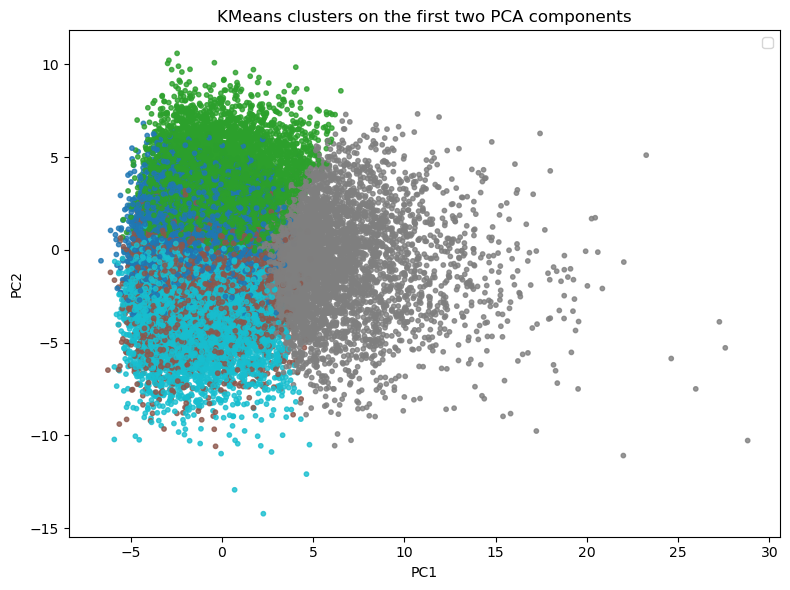

In [148]:
import numpy as np
import matplotlib.pyplot as plt

cluster = cluster.astype(int)  # safety

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    Xpca[:, 0], Xpca[:, 1],
    c=cluster,              
    s=10,
    alpha=0.8,
    cmap="tab10"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters on the first two PCA components")


plt.legend()
plt.tight_layout()
plt.show()


In [149]:
import numpy as np
print("Unique labels:", np.unique(cluster))
print("Counts:", np.bincount(cluster.astype(int)))


Unique labels: [0 1 2 3 4]
Counts: [7170 8698 5802 4847 7646]


In [150]:
df['cluster'] = cluster
df['cluster'] = cluster.astype(int)
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,EST,EST_time,AGR,AGR_time,CSN,CSN_time,OPN,OPN_time,target,cluster
0,3.0,2.0,2.0,4.0,4.0,4.0,5.0,3.0,1.0,3.0,...,0.44,46.155,0.24,82.665,0.10,62.022,0.10,40.415,NaN,4
1,3.0,4.0,1.0,4.0,3.0,2.0,2.0,4.0,3.0,5.0,...,0.42,36.420,-0.14,86.422,0.10,56.401,0.26,38.205,0.0,2
2,3.0,3.0,4.0,4.0,5.0,3.0,3.0,5.0,2.0,2.0,...,0.42,50.268,0.50,58.487,0.18,44.737,0.34,51.454,NaN,0
3,1.0,5.0,1.0,5.0,2.0,4.0,1.0,5.0,3.0,5.0,...,0.64,59.489,0.22,59.080,0.18,66.815,0.32,58.911,NaN,4
4,1.0,4.0,3.0,5.0,1.0,2.0,2.0,4.0,2.0,4.0,...,0.46,39.848,0.40,97.554,0.24,45.858,0.42,48.390,0.0,4


In [151]:
features = df.columns.drop(['ID', 'target', 'cluster'], errors='ignore')

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_means = df.groupby('cluster')[features].mean()
cluster_medians = df.groupby('cluster')[features].median()
global_mean = df[features].mean()
delta = cluster_means - global_mean
top_pos = delta.apply(lambda s: s.nlargest(5).index.tolist(), axis=1)
top_neg = delta.apply(lambda s: s.nsmallest(5).index.tolist(), axis=1)



In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


features = df.columns.drop(['ID', 'target', 'cluster'], errors='ignore')
assert 'cluster' in df.columns, "df must contain a 'cluster' column"

cluster_sizes  = df['cluster'].value_counts().sort_index()
cluster_means  = df.groupby('cluster')[features].mean(numeric_only=True)
global_mean    = df[features].mean(numeric_only=True)
delta          = cluster_means.subtract(global_mean, axis=1)

top_pos = delta.apply(lambda s: s.nlargest(5).index.tolist(), axis=1)
top_neg = delta.apply(lambda s: s.nsmallest(5).index.tolist(), axis=1)

summary = pd.DataFrame({
    "cluster_size": cluster_sizes,
    "top_pos(5)": top_pos,
    "top_neg(5)": top_neg,
})

display(summary.style.set_properties(**{"white-space": "pre-wrap"}))


,cluster_size,top_pos(5),top_neg(5)
cluster,,,
0,7170,"['EXT7', 'EXT9', 'CSN2', 'EXT1', 'EXT5']","['AGR1_E', 'EST4_E', 'EXT1_E', 'OPN4_E', 'OPN2_E']"
1,8698,"['EXT10_E', 'EXT8_E', 'EXT3', 'CSN5', 'EXT5']","['AGR1_E', 'CSN8_E', 'AGR3_E', 'OPN2_E', 'AGR4_E']"
2,5802,"['AGR5', 'AGR7', 'AGR1', 'EXT2', 'EXT6']","['EXT1_E', 'CSN8_E', 'CSN10_E', 'OPN2_E', 'EXT4_E']"
3,4847,"['EXT1_E', 'CSN8_E', 'EST4_E', 'OPN2_E', 'AGR1_E']","['OPN8', 'OPN1', 'OPN7', 'EXT8', 'EST10']"
4,7646,"['EST1', 'EST10', 'EST6', 'EXT10', 'EST8']","['EXT1_E', 'EST4_E', 'EXT4_E', 'EXT8_E', 'EXT10_E']"


### Put it all together:

In [153]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_pipeline(df, n_components = 20, n_clusters = 5, random_state=42):
    X = df.drop(columns=["target", "ID"])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(X_pca)

    return {
        "n_components": n_components,
        "n_clusters": n_clusters,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": km.inertia_,
    }


In [154]:
metrics = run_pipeline(df)

print(metrics)

{'n_components': 20, 'n_clusters': 5, 'explained_variance': np.float64(0.5025681698562569), 'silhouette': 0.08527382529978939, 'inertia': 1349390.501287404}
